In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

### Load Data

In [3]:
EU_shp = gpd.read_file("C:/Users/bruce/R/aiv-gpboost/EU_100km_fishnet_simple_by_distance/EU_100km_fishnet_simple_by_distance.shp")

In [8]:
bird_folder_path = Path(r"C:/Users/bruce/R/aiv-gpboost/rcon-abundance-new")

bird_names = []
for p in bird_folder_path.iterdir():
    if p.is_dir():
        #print(p.name.removesuffix("_outputs"))
        bird_names.append(p.name.removesuffix("_outputs"))
print(bird_names[:5])
print("number of bird: ", len(bird_names))

['Accipiter_nisus', 'Aix_galericulata', 'Anas_acuta', 'Anas_crecca', 'Anas_platyrhynchos']
number of bird:  67


In [9]:
for bird_name in bird_names:
    #print("bird name: ", bird_name)
    output_folder = Path(r"C:/Users/bruce/R/aiv-gpboost/all-birds-abd-new")
    output_folder.mkdir(parents=True, exist_ok=True)

    ### Load Data
    abd_path = bird_folder_path/f"{bird_name}_outputs"/f"{bird_name}_reconstruction_abundance.csv"
    abd = pd.read_csv(abd_path)

    ### Save Data
    saved_abd = abd[['Id', 'year_number', 'month_number','relative_abundance']].copy()
    saved_abd.to_csv(output_folder / f"{bird_name}.csv",index=False)

    print(f"{bird_name} data saved successful !")


Accipiter_nisus data saved successful !
Aix_galericulata data saved successful !
Anas_acuta data saved successful !
Anas_crecca data saved successful !
Anas_platyrhynchos data saved successful !
Anser_anser data saved successful !
Ardea_alba data saved successful !
Ardea_cinerea data saved successful !
Arenaria_interpres data saved successful !
Athene_noctua data saved successful !
Aythya_ferina data saved successful !
Aythya_fuligula data saved successful !
Branta_bernicla data saved successful !
Branta_canadensis data saved successful !
Bucephala_clangula data saved successful !
Buteo_buteo data saved successful !
Calidris_alba data saved successful !
Calidris_alpina data saved successful !
Charadrius_hiaticula data saved successful !
Chroicocephalus_ridibundus data saved successful !
Ciconia_ciconia data saved successful !
Columba_livia data saved successful !
Columba_palumbus data saved successful !
Corvus_corax data saved successful !
Corvus_cornix data saved successful !
Cygnus_c

In [ ]:
#abd_folder_path = Path(r"C:/Users/bruce/R/aiv-gpboost/rcon-abundance/Accipiter_nisus_outputs")
#for p in abd_folder_path.iterdir():
#    print(p)

C:\Users\bruce\R\aiv-gpboost\rcon-abundance\Accipiter_nisus_outputs\Accipiter_nisus_feature_importance_gain.csv
C:\Users\bruce\R\aiv-gpboost\rcon-abundance\Accipiter_nisus_outputs\Accipiter_nisus_model_performance.csv
C:\Users\bruce\R\aiv-gpboost\rcon-abundance\Accipiter_nisus_outputs\Accipiter_nisus_random_effect_summary.csv
C:\Users\bruce\R\aiv-gpboost\rcon-abundance\Accipiter_nisus_outputs\Accipiter_nisus_reconstruction_abundance.csv


###  Average Abundance

In [ ]:
bird_name = bird_names[0]
print("bird name: ", bird_name)
abd_path = bird_folder_path/f"{bird_name}_outputs"/f"{bird_name}_reconstruction_abundance.csv"
abd = pd.read_csv(abd_path)

print(abd.groupby(["Id", "year_number", "month_number"]).size().max())

vmin = abd["relative_abundance"].min()
vmax = abd["relative_abundance"].max()
print("minimum of relative abundance:", round(vmin, 3))
print("maxmum of relative abundance:", round(vmax,3))

print(abd[['Id', 'year_number', 'month_number','relative_abundance']].head())

bird name:  Accipiter_nisus
1
minimum of relative abundance: 0.764
maxmum of relative abundance: 2.268


,Id,year_number,month_number,relative_abundance
0,3,2021,1,0.992740
1,3,2021,2,1.061843
2,3,2021,3,1.115784
3,3,2021,4,1.212873
4,3,2021,5,1.069947
...,...,...,...,...
11899,18790,2022,8,1.289631
11900,18790,2022,9,1.302985
11901,18790,2022,10,1.186634
11902,18790,2022,11,1.077898


In [15]:
bird_name = bird_names[0]
print("bird name: ", bird_name)
abd_path = bird_folder_path/f"{bird_name}_outputs"/f"{bird_name}_reconstruction_abundance.csv"
abd = pd.read_csv(abd_path)

#print(abd.groupby(["Id", "year_number", "month_number"]).size().max())

vmin = abd["relative_abundance"].min()
vmax = abd["relative_abundance"].max()
print("minimum of relative abundance:", round(vmin, 3))
print("maxmum of relative abundance:", round(vmax,3))

print(abd[['Id', 'year_number', 'month_number','relative_abundance']].head())

abd["date"] = pd.to_datetime(dict(year=abd["year_number"], month=abd["month_number"], day=15)) 
abd_period1 = abd[(abd["date"] >= '2021-05-01') & (abd["date"] <= '2021-10-31')]
abd_period2 = abd[(abd["date"] >= '2021-11-01') & (abd["date"] <= '2022-04-30')]
abd_period3 = abd[(abd["date"] >= '2022-05-01') & (abd["date"] <= '2022-10-31')]

abd_period1_mean = (
    abd_period1
    .groupby("Id")["relative_abundance"]
    .mean()
    .rename("mean_abundance")
    .reset_index()
)

abd_period2_mean = (
    abd_period2
    .groupby("Id", as_index=False)
    .agg(mean_abundance=("relative_abundance", "mean"))
)

abd_period3_mean = (
    abd_period3
    .groupby("Id", as_index=False)
    .agg(mean_abundance=("relative_abundance", "mean"))
)

print(f"abd_period1: \n {abd_period1_mean.head()}")
print(f"abd_period2: \n {abd_period2_mean.head()}")
print(f"abd_period3: \n {abd_period3_mean.head()}")

bird name:  Accipiter_nisus
minimum of relative abundance: 0.777
maxmum of relative abundance: 2.276
   Id  year_number  month_number  relative_abundance
0   3         2021             1            1.020296
1   3         2021             2            1.035725
2   3         2021             3            1.085793
3   3         2021             4            1.198204
4   3         2021             5            1.042596
abd_period1: 
     Id  mean_abundance
0    3        1.090894
1   27        1.140881
2  140        1.107328
3  210        1.153295
4  233        1.021614
abd_period2: 
     Id  mean_abundance
0    3        1.052009
1   27        1.110237
2  140        1.110836
3  210        1.125368
4  233        1.060686
abd_period3: 
     Id  mean_abundance
0    3        1.075649
1   27        1.119378
2  140        1.137190
3  210        1.178635
4  233        1.029222


In [14]:
abd_year_mean = (
    abd
    .groupby(["Id", "year_number"])["relative_abundance"]
    .mean()
    .rename("mean_abundance")
    .reset_index()
)

print(f"Annual average abundance: \n {abd_year_mean.head()}")

Annual average abundance: 
     Id  year_number  mean_abundance
0    3         2021        1.087622
1    3         2022        1.065645
2   27         2021        1.131574
3   27         2022        1.105152
4  140         2021        1.075119


### Single Month Abundance Visualization

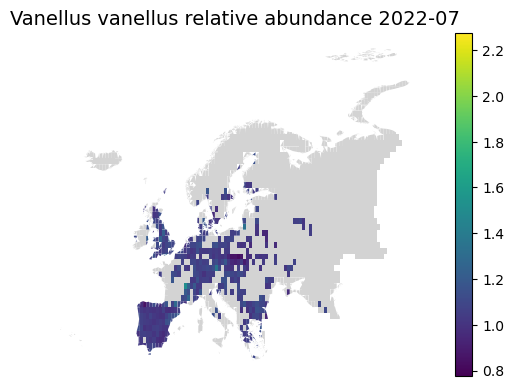

In [16]:
plot_year = 2022
plot_month = 7

plot_df = abd[
    (abd["year_number"] == plot_year) &
    (abd["month_number"] == plot_month)
].copy()

map_df = EU_shp.merge(
    plot_df[["Id", "relative_abundance"]],
    on="Id",
    how="left"
)

fig, ax = plt.subplots(figsize=(6, 4))

map_df.plot(
    column="relative_abundance",
    ax=ax,
    cmap="viridis",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    f"Vanellus vanellus relative abundance {plot_year}-{plot_month:02d}",
    fontsize=14
)
ax.axis("off")

plt.tight_layout()
plt.show()

### Save Average Abundance Visualization (Batch)

In [89]:
def plot_save(bird_name, abd, period):

    output_folder = bird_folder_path/f"{bird_name}_outputs"/"plot_python"
    output_folder.mkdir(parents=True, exist_ok=True)

    plot_df = pd.merge(EU_shp, abd, on="Id", how="left")

    if period == 1:
        title_name = "Mean Relative Abundance 2021-05 ~ 2021-10"
        save_name ='mean_relative_abundance_2021_05_2021_10'
    elif period == 2:
        title_name = "Mean Relative Abundance 2021-11 ~ 2022-04"
        save_name ='mean_relative_abundance_2021_11_2022_04'
    else:
        title_name = "Mean Relative Abundance 2022-05 ~ 2022-10"
        save_name ='mean_relative_abundance_2022_05_2022_10'

    #print("all grids: ", len(plot_df))
    #print("NOT NA grids: ", len(plot_df[~plot_df["mean_abundance"].isna()]))
    #print("NA grids: ", len(plot_df[plot_df["mean_abundance"].isna()]))

    fig, ax = plt.subplots(figsize=(8,6))

    plot_df.plot(
        column="mean_abundance",
        cmap="viridis",
        legend=True,
        missing_kwds={"color": "lightgrey"},
        ax=ax
    )

    ax.set_title(title_name)
    plt.savefig(f"{output_folder}/{save_name}.png", dpi=400, bbox_inches="tight")
    plt.close(fig)
    print(f"{bird_name} period{period} image saved successful !")



for bird_name in bird_names[66:67]:
    print("bird name: ", bird_name)

    ### Load Data
    abd_path = bird_folder_path/f"{bird_name}_outputs"/f"{bird_name}_reconstruction_abundance.csv"
    abd = pd.read_csv(abd_path)

    #print(abd.groupby(["Id", "year_number", "month_number"]).size().max())

    vmin = abd["relative_abundance"].min()
    vmax = abd["relative_abundance"].max()
    print("minimum of relative abundance:", round(vmin, 3))
    print("maxmum of relative abundance:", round(vmax,3))

    abd[['Id', 'year_number', 'month_number','relative_abundance']]

    ### Calculate Abundance Mean in period1, period2, and period3
    abd["date"] = pd.to_datetime(dict(year=abd["year_number"], month=abd["month_number"], day=15)) 
    abd_period1 = abd[(abd["date"] >= '2021-05-01') & (abd["date"] <= '2021-10-31')]
    abd_period2 = abd[(abd["date"] >= '2021-11-01') & (abd["date"] <= '2022-04-30')]
    abd_period3 = abd[(abd["date"] >= '2022-05-01') & (abd["date"] <= '2022-10-31')]

    abd_period1_mean = (
        abd_period1
        .groupby("Id")["relative_abundance"]
        .mean()
        .rename("mean_abundance")
        .reset_index()
    )

    abd_period2_mean = (
        abd_period2
        .groupby("Id", as_index=False)
        .agg(mean_abundance=("relative_abundance", "mean"))
    )

    abd_period3_mean = (
        abd_period3
        .groupby("Id", as_index=False)
        .agg(mean_abundance=("relative_abundance", "mean"))
    )

    #print(f"abd_period1: \n {abd_period1_mean.head()}")
    #print(f"abd_period2: \n {abd_period2_mean.head()}")
    #print(f"abd_period3: \n {abd_period3_mean.head()}")

    ### Plot & Save Images
    plot_save(bird_name,abd_period1_mean, period=1)
    plot_save(bird_name,abd_period2_mean, period=2)
    plot_save(bird_name, abd_period3_mean, period=3)

    

bird name:  Vanellus_vanellus
minimum of relative abundance: 2.456
maxmum of relative abundance: 158.158
Vanellus_vanellus period1 image saved successful !
Vanellus_vanellus period2 image saved successful !
Vanellus_vanellus period3 image saved successful !


### Feature Importance (Gain)

In [72]:
bird_types = pd.read_csv("C:/Users/bruce/R/aiv-gpboost/bird_type_lookup.csv")
bird_types["bird_name"] = bird_types["birdname"].str.replace(" ", "_", regex=False)

waterbirds = bird_types[["birdname", "bird_name"]][bird_types["waterbird"] == 1]
n_waterbirds = bird_types[["birdname", "bird_name"]][bird_types["waterbird"] == 0]

print(len(waterbirds))
print(len(n_waterbirds))

46
21


In [73]:
def get_FI(bird_cols, FI_cols):
    all_lc_FI = pd.DataFrame(FI_cols)
    all_lc_FI.columns = ['feature']
    all_lc_FI["total_rank_point"] = 0

    for bird_name in bird_cols:
        FI_path = bird_folder_path/f"{bird_name}_outputs"/f"{bird_name}_feature_importance_gain.csv"
        FI = pd.read_csv(FI_path)

        lc_FI = FI[FI["feature"].isin(lc_cols)].sort_values("importance", ascending=False).copy()
        lc_FI["rank_point"] = np.arange(len(lc_FI), 0, -1)

        all_lc_FI = pd.merge(all_lc_FI, lc_FI[["feature", "rank_point"]], on="feature", how="left")
        all_lc_FI["total_rank_point"] = all_lc_FI["total_rank_point"] + all_lc_FI["rank_point"]
        all_lc_FI = all_lc_FI[["feature", "total_rank_point"]]

    all_lc_FI = all_lc_FI.sort_values("total_rank_point", ascending=False)
    return all_lc_FI


lc_cols = ['built_MEAN', 'flooded_vegetation_MEAN', 'shrub_and_scrub_MEAN','trees_MEAN',
            'crops_MEAN', 'grass_MEAN', 'water_MEAN', 'snow_and_ice_MEAN', 'bare_MEAN']

all_lc_FI = get_FI(bird_names, lc_cols)
waterbirds_lc_FI = get_FI(waterbirds["bird_name"], lc_cols)
n_waterbirds_lc_FI = get_FI(n_waterbirds["bird_name"], lc_cols)

In [90]:
#print(f"all birds: \n {all_lc_FI}")
#print(f"waterbirds: \n {waterbirds_lc_FI}")
#print(f"non waterbirds: \n {n_waterbirds_lc_FI}")

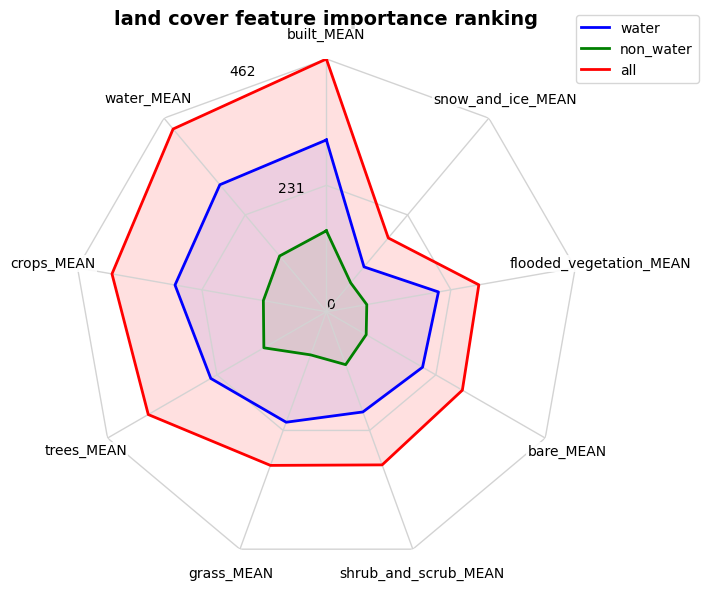

In [ ]:
features = (
    all_lc_FI
    .sort_values("total_rank_point", ascending=False)["feature"]
    .tolist()
)

def get_values(df, features):
    s = df.set_index("feature")["total_rank_point"]
    return [s.get(f, 0) for f in features]

all_values = get_values(all_lc_FI, features)
water_values = get_values(waterbirds_lc_FI, features)
non_water_values = get_values(n_waterbirds_lc_FI, features)

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

all_values += all_values[:1]
water_values += water_values[:1]
non_water_values += non_water_values[:1]

max_value = all_lc_FI["total_rank_point"].max()
yticks = [0, max_value / 2, max_value]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(1)

# Turn off the default circular grid
ax.grid(False)
ax.spines["polar"].set_visible(False)

# Draw a polygon mesh yourself
for y in yticks[1:]:
    ax.plot(
        angles,
        [y] * len(angles),
        color="lightgrey",
        linewidth=1,
        linestyle="-"
    )

# Manually draw the radial lines for each feature.
for angle in angles[:-1]:
    ax.plot(
        [angle, angle],
        [0, max_value],
        color="lightgrey",
        linewidth=1
    )

ax.plot(angles, water_values, color="blue", linewidth=2, label="water")
ax.fill(angles, water_values, color="blue", alpha=0.08)

ax.plot(angles, non_water_values, color="green", linewidth=2, label="non_water")
ax.fill(angles, non_water_values, color="green", alpha=0.08)

ax.plot(angles, all_values, color="red", linewidth=2, label="all")
ax.fill(angles, all_values, color="red", alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

label_radius = max_value * 1.10

for angle, feature in zip(angles[:-1], features):
    ax.text(
        angle,
        label_radius,
        feature,
        fontsize=10,
        ha="center",
        va="center",
        zorder=20,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1)
    )

ax.set_ylim(0, max_value)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(x)}" for x in yticks], fontsize=10)

ax.set_title(
    "land cover feature importance ranking",
    fontsize=14,
    fontweight="bold",
    pad=25
)

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.show()

### Model Performance

In [71]:
all_SRC = []

for bird_name in bird_names:
    SRC_path = bird_folder_path/f"{bird_name}_outputs"/f"{bird_name}_model_performance.csv"
    SRC = pd.read_csv(SRC_path)
    all_SRC.append(SRC)

all_SRC = pd.concat(all_SRC, axis=0, ignore_index=True)
all_SRC.head()

,birdname,checklist_path,response_transform,gpboost_likelihood,n_train,n_val,n_train_id,n_val_id,train Spearman SRC,validation Spearman SRC,train MAE,validation MAE,train_spearman_src,validation_spearman_src,train_mae,validation_mae
0,Accipiter nisus,/content/checklist/ebird_filtered_checklist/^A...,count,negative_binomial,47555,5283,457,443,0.435901,0.252677,0.216902,0.246174,0.435901,0.252677,0.216902,0.246174
1,Aix galericulata,/content/checklist/ebird_filtered_checklist/^A...,count,negative_binomial,5877,653,78,69,0.821679,0.481216,1.173490,2.334832,0.821679,0.481216,1.173490,2.334832
2,Anas acuta,/content/checklist/ebird_filtered_checklist/^A...,count,negative_binomial,16181,1797,267,243,0.663215,0.480300,7.040500,8.937440,0.663215,0.480300,7.040500,8.937440
3,Anas crecca,/content/checklist/ebird_filtered_checklist/^A...,count,negative_binomial,81415,9046,451,442,0.584526,0.525332,20.510811,22.698290,0.584526,0.525332,20.510811,22.698290
4,Anas platyrhynchos,/content/checklist/ebird_filtered_checklist/^A...,count,negative_binomial,347888,38654,590,590,0.542368,0.517302,12.990762,13.330022,0.542368,0.517302,12.990762,13.330022


In [79]:
all_SRC["bird_type"] =np.where(all_SRC["birdname"].isin(waterbirds["birdname"]), "waterbird", "non_waterbird")
all_SRC = all_SRC[['birdname', 'bird_type', 'n_train', 'n_val', 'train_spearman_src', 'validation_spearman_src']]
all_SRC.head()

,birdname,bird_type,n_train,n_val,train_spearman_src,validation_spearman_src
0,Accipiter nisus,non_waterbird,47555,5283,0.435901,0.252677
1,Aix galericulata,waterbird,5877,653,0.821679,0.481216
2,Anas acuta,waterbird,16181,1797,0.663215,0.480300
3,Anas crecca,waterbird,81415,9046,0.584526,0.525332
4,Anas platyrhynchos,waterbird,347888,38654,0.542368,0.517302


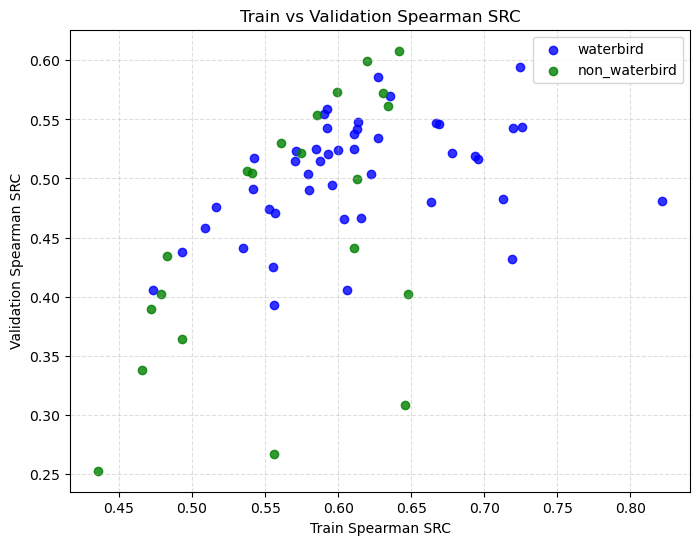

In [88]:
plt.figure(figsize=(8, 6))

for bird_type, color in {
    "waterbird": "blue",
    "non_waterbird": "green"
}.items():
    df = all_SRC[all_SRC["bird_type"] == bird_type]

    plt.scatter(
        df["train_spearman_src"],
        df["validation_spearman_src"],
        color=color,
        label=bird_type,
        alpha=0.8
    )

#plt.axvline(x=0.5, color="grey", linestyle="--", linewidth=1)
#plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.grid(True, linestyle="--", alpha=0.4)

plt.xlabel("Train Spearman SRC")
plt.ylabel("Validation Spearman SRC")
plt.title("Train vs Validation Spearman SRC")
plt.legend()